<b> research | Fabrica un gran Sharpe sin alpha </b>

Simula 500 estrategias sin ningún alpha:

```python
import numpy as np

np.random.seed(42)

T = 252 * 3
M = 500

returns = np.random.normal(
    0,
    0.01,
    size=(T, M)
)

sharpe = (
    returns.mean(axis=0)
    / returns.std(axis=0, ddof=1)
    * np.sqrt(252)
)
```

Calcula:

```text
mean Sharpe
median Sharpe
95th percentile Sharpe
maximum Sharpe
number Sharpe > 1
```

↓
Después repite todo el experimento completo 1,000 veces y almacena solamente:

$ SR_{\max}^{(k)} $


| Estadística de \(SR_{\max}\) | Valor |
|---|---:|
| Mean | |
| Median | |
| 5% | |
| 95% | |


Haz además un histograma de:

$$SR_{\max}.$$

Ahora viene la parte importante.

Cada estrategia fue generada mediante:

$$r_t \sim N(0, \sigma^2).$$

Por construcción:

$$\text{true Sharpe} = 0.$$

Sin embargo, probablemente encontrarás máximos bastante atractivos.

Explica por qué esto no es overfitting del modelo en el sentido tradicional. No entrenaste ningún ML.

Lo que hiciste fue:

$\text{selection over noise}.$ 

- <b> Respuesta </b>
> No es overfitting tradicional porque no entrenaste ni ajustaste un modelo a los datos: cada estrategia se generó de forma aleatoria e independiente, sin parámetros aprendidos, reglas optimizadas ni predicciones.

> El Sharpe máximo parece atractivo porque evaluaste muchas estrategias con retorno esperado cero y luego elegiste la que, por azar, tuvo la mejor realización histórica. Es decir, no encontraste alpha; seleccionaste el extremo favorable de muchas muestras de ruido.

> A esto se le llama selection over noise o sesgo de selección/múltiples pruebas. Cuantas más estrategias aleatorias pruebes, mayor será la probabilidad de que alguna muestre un Sharpe alto por casualidad, aunque su Sharpe verdadero sea cero.



Finalmente responde:

> Si aumento $M$ de 500 a 50,000 manteniendo $T$ fijo, ¿qué esperas que ocurra con el mejor Sharpe observado?

No necesitas simularlo. Razona usando extremos de una distribución.

Al aumentar $ M$  de 500 a 50,000, comparas muchas más estrategias que solo contienen ruido. Aunque todas tengan Sharpe verdadero igual a cero, es mucho más probable que alguna presente un rendimiento históricamente muy favorable por azar.


In [4]:
import numpy as np
np.random.seed(42)
T = 252 * 3
M = 500

returns = np.random.normal(0,0.01,size=(T, M))

sharpe = (
    returns.mean(axis=0)
    / returns.std(axis=0, ddof=1)
    * np.sqrt(252)
)

def metricas (sharpe):
    mean_sharpe = sharpe.mean() 
    median_sharpe = np.median(sharpe)
    nin_percen = np.percentil(Sharpe, 95)
    max_sharpe = sharpe.max()
    num_sharpe = np.sum(sharpe > 1)
    return {'mean_sharpe' : mean_sharpe, 
            'median sharpe' : median_sharpe, 
            'nin_percen':nin_percen,
            'max_sharpe' : max_sharpe, 
            'num_sharpe':num_sharpe}

n_experimentos = 1000  # usa 500 si eso te pidieron
max_sharpes = np.empty(n_experimentos)

for k in range(n_experimentos):
    returns = np.random.normal(0, 0.01, size=(T, M))

    sharpes = (
        returns.mean(axis=0)
        / returns.std(axis=0, ddof=1)
        * np.sqrt(252)
    )

    max_sharpes[k] = sharpes.max()
    resumen_maximos = {
    "mean": max_sharpes.mean(),
    "median": np.median(max_sharpes),
    "5%": np.percentile(max_sharpes, 5),
    "95%": np.percentile(max_sharpes, 95),
}

resumen_maximos

{'mean': np.float64(1.7564294836754784),
 'median': np.float64(1.7319694120115208),
 '5%': np.float64(1.4484317966813878),
 '95%': np.float64(2.1581743433648866)}

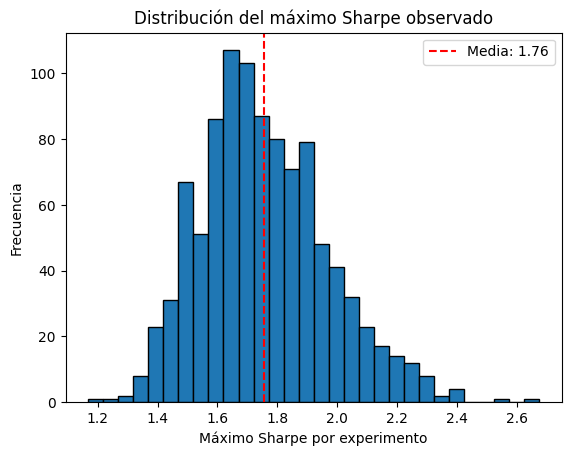

In [5]:
import matplotlib.pyplot as plt

plt.hist(max_sharpes, bins=30, edgecolor="black")
plt.axvline(max_sharpes.mean(), color="red", linestyle="--",
            label=f"Media: {max_sharpes.mean():.2f}")
plt.title("Distribución del máximo Sharpe observado")
plt.xlabel("Máximo Sharpe por experimento")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

<b >Quant Desk + Research Governance | ¿Qué cuenta como “una hipótesis”? </b>

Tu researcher reporta:

“Probé una estrategia momentum y obtuvo Sharpe OOS = 1.7.”

Pero al reconstruir el trabajo descubres que probó:

```text
lookback:
5, 10, 20, 40, 60 días

holding period:
1, 5, 10 días

universe:
S&P 500
<!-- Nasdaq 100 -->
Russell 1000

volatility filter:
ON / OFF

winsorization:
1%, 2%, 5%
```

No calcules simplemente:

\[5 \times 3 \times 3 \times 2 \times 3.\]

Primero responde algo más profundo:

> ¿Cada combinación debe considerarse necesariamente una hipótesis independiente?

Piensa en correlación entre estrategias: `lookback=20` y `lookback=21` probablemente no representan dos experimentos independientes.

- <b> Respuesta </b>
> Cada combinación evaluada no debe tratarse como una hipótesis completamente independiente si las decisiones posteriores se tomaron al observar resultados anteriores. Al ver qué parámetros, filtros o combinaciones parecían funcionar, fui dirigiendo las siguientes pruebas hacia regiones más prometedoras. Por tanto, el experimento dejó de ser una búsqueda aleatoria fija: las pruebas posteriores incorporaron información del mismo conjunto de datos.
Esto aumenta el riesgo de obtener un resultado aparentemente bueno por azar, ya que el desempeño histórico influyó en la construcción y selección de las combinaciones siguientes. Aunque cada ajuste individual parezca razonable, el proceso completo equivale a realizar muchas pruebas adaptativas sobre el mismo ruido.

Ahora diseña para tu Quant Desk un Research Search Log mínimo:

```text
research_id
RS-2026-001

economic_hypothesis
Las acciones con mayor momentum ajustado por volatilidad presentan retornos
futuros superiores debido a la persistencia de tendencias y al retraso en la
incorporación de información por parte del mercado.

dataset_version
prices_adjusted_v1.0_2026-09-28

universe
Acciones líquidas del S&P 500, excluyendo ETFs, ADRs y acciones con historial
insuficiente durante el periodo de evaluación.

parameters_tested
lookback_momentum: [21, 63, 126, 252]
holding_period: [5, 21]
portfolio_size: [10%, 20%]
volatility_lookback: [21, 63]

variants_tested
Momentum simple, momentum ajustado por volatilidad, long-only y long-short,
con rebalanceo semanal y mensual.

selection_metric
Sharpe ratio anualizado en el periodo de validación, después de costos de
transacción estimados.

selected_variant
Momentum ajustado por volatilidad; lookback de 126 días; holding period de 21
días; portafolio long-short con el 10% superior y 10% inferior.

train_period
2015-01-01 a 2021-12-31

validation_period
2022-01-01 a 2023-12-31

final_OOS_period
2024-01-01 a 2025-12-31

number_of_trials
64

effective_number_of_trials
Aproximadamente 20, ya que varias configuraciones comparten parámetros,
universo y señales altamente correlacionadas.

selection_rule
Seleccionar únicamente variantes con Sharpe positivo en entrenamiento y
validación, drawdown dentro del límite definido y desempeño positivo después
de costos. En caso de empate, elegir la configuración más simple.

frozen_at
2023-12-31
```

Después considera dos workflows.

### Workflow A

100 variantes $\rightarrow$ escojo mejor Sharpe $\rightarrow$ reporto ese Sharpe.

### Workflow B

100 variantes $\rightarrow$ selección en Train/Validation $\rightarrow$ freeze $\rightarrow$ un único Final OOS intacto.

Explica por qué B protege mejor la inferencia.

- <b> RESPUESTA  </b>

> El Workflow B protege mejor la inferencia porque evita el data snooping. Las 100 variantes se comparan únicamente usando los periodos de Train y Validation; después se elige una variante, se congelan sus reglas y se evalúa una sola vez en un periodo Final OOS que no participó en ninguna decisión.
Por ello, el resultado OOS funciona como una prueba genuina de generalización: no fue utilizado para ajustar parámetros, elegir regiones prometedoras ni descartar resultados desfavorables. En contraste, en el Workflow A se reporta el mejor Sharpe entre 100 pruebas, por lo que es probable que esté inflado por selección sobre ruido.
El análisis posterior al test puede servir para generar nuevas hipótesis, pero ya no debe usarse para validar la estrategia original. Si se modifica la estrategia a partir de ese análisis, se inicia un nuevo experimento con un nuevo periodo OOS intacto.

Pero ahora la pregunta difícil:

Ejecutas B. El Final OOS sale mal. Modificas el lookback basándote en ese resultado y vuelves a probar sobre exactamente el mismo Final OOS. ¿Sigue siendo OOS?

Tu respuesta debe distinguir:

- <b> Respuesta </b>
> El periodo dejó de ser una prueba genuina e independiente porque su resultado influyó en la modificación del lookback. Al volver a probar sobre ese mismo periodo, estás dirigiendo el experimento con información que proviene del supuesto test final.

> Por tanto, ese conjunto ahora forma parte del proceso de selección y ajuste; se convirtió, en la práctica, en otro conjunto de validación. Para evaluar la estrategia modificada necesitarías congelarla nuevamente y probarla en un periodo OOS nuevo, que no haya sido consultado antes.

$$\text{chronologically future}$$

de

$$\text{informationally untouched}.$$

Finalmente redacta una sola regla para tu Quant Desk que determine cuándo un dataset pierde su condición de Final OOS.

- Un dataset pierde su condición de Final OOS en el momento en que cualquiera de sus resultados se utiliza para tomar, justificar o modificar una decisión de investigación —por ejemplo, parámetros, señales, universo, reglas de ejecución o selección de estrategia.



# <b> Martes </b>

<b>probabilidad </b>

**Overfitting sin ML: optimiza un parámetro que no contiene información**
Genera retornos completamente aleatorios:

```python
import numpy as np

np.random.seed(117)

T = 2000

r = np.random.normal(
    0,
    0.01,
    T
)

train = r[:1000]
test = r[1000:]
```

No existe alpha:

$$r_t \sim N(0, \sigma^2).$$

Ahora inventaremos estrategias absurdas.

Para cada:

$$k = 2, 3, \dots, 100$$

define:

$$s_t^{(k)} = \begin{cases} +1 & \text{si } t \bmod k = 0 \\ -1 & \text{en otro caso.} \end{cases}$$

El parámetro $k$ obviamente no contiene información económica.

Calcula para cada $k$:

$$r_{t,k}^{strategy} = s_t^{(k)} r_t$$

y su Sharpe solamente en Train.

Selecciona:

$$k^* = \arg \max_{k} SR_k^{Train}.$$

Ahora congela $k^*$ y evalúa exactamente esa estrategia en Test.

Entrega:


| Resultado | Valor |
|---|---:|
| Número de \(k\) probados | |
| \(k^*\) | |
| Best Train Sharpe | |
| Test Sharpe de \(k^*\) | |
| Median Train Sharpe | |

Después repite todo el experimento 500 veces y guarda:

$$SR_{winner}^{Train}$$

y

$$SR_{winner}^{Test}.$$

Compara:

$$E[SR_{winner}^{Train}]$$

contra

$$E[SR_{winner}^{Test}].$$

No necesitas hacer más gráficos.

La pregunta importante es:

> ¿Por qué Train Sharpe del ganador está sesgado hacia arriba aunque cada estimador individual de Sharpe esté centrado aproximadamente alrededor de cero?


Quiero que lo expliques mediante:

$$\max(\hat{\theta}_1, \dots, \hat{\theta}_M)$$

y no simplemente diciendo "porque hubo overfitting".

- <b> RESPUESTA </b>
>  Cada estimador individual de Sharpe puede estar centrado cerca de cero:
$ E[\hat{\theta}_i]\approx0$, porque ninguna estrategia tiene alpha verdadero. Pero el proceso no reporta un estimador individual elegido antes de ver los datos. Reporta: $ \max(\hat{\theta}_1,\dots,\hat{\theta}_M)$.El operador $ \max $  cambia la distribución. Entre $ M $  estimaciones ruidosas habrá valores negativos y positivos; al tomar sólo el mayor, descartas sistemáticamente los negativos y seleccionas el extremo positivo.

> el Train Sharpe del ganador está sesgado hacia arriba no porque exista alpha, sino porque el criterio de selección elige deliberadamente la realización de ruido más favorable de entre muchas alternativas. Cuanto mayor sea \(M\), mayor tiende a ser ese máximo esperado.


Después responde:

> ¿Por qué Test destruye la ventaja aunque utilices exactamente $k^*$ y no vuelvas a optimizar nada?

la intuición estadística:

$$\text{selection exploits estimation noise}$$

mientras que una muestra nueva genera otro realization noise. 

- <b> Respuesta </b>

> $ k^* $ ganó en Train porque estuvo asociado, por azar, con la realización de ruido más favorable de esa muestra:

 
 > Al congelar $ k^* $ y aplicarlo en Test no vuelves a optimizar, lo cual evita una nueva selección sesgada, pero tampoco convierte a $ k^* $  en una señal con alpha. Test contiene una nueva realización independiente de retornos aleatorios:

 > El ruido favorable que hizo que $ k^* $  pareciera atractivo en Train no tiene motivo para repetirse en Test. Por tanto:

> En una muestra Test concreta el Sharpe puede resultar positivo o negativo, pero al repetir muchos experimentos ambas realizaciones se compensan. Test destruye la ventaja aparente porque mide la estrategia sobre ruido nuevo, mientras que Train había seleccionado precisamente el ruido favorable del pasado.
 

In [2]:
import numpy as np

np.random.seed(117)

T = 2000

r = np.random.normal(0,0.01,T)
train = r[:1000]
test  = r[1000:]

t = np.arange(T)
ks = range(2,101)
def sharpe(x):
    return np.sqrt(252) * x.mean() / x.std(ddof=1)
train_sharpes = {}
test_sharpes =  {}
for k in ks: 
    # +1 cuando t es multiplo de k, -1 en los demas instantes 
    signal = np.where(t % k == 0,1.0,-1.0)
    strategy_returns = signal * r 
    strategy_train = strategy_returns[:1000]
    strategy_test = strategy_returns[1000:]
    train_sharpes[k] = sharpe(strategy_train)
    test_sharpes[k] =  sharpe(strategy_test)

# Selección usando ÚNICAMENTE Train
k_star = max(train_sharpes, key=train_sharpes.get)
best_train_sharpe = train_sharpes[k_star]
test_sharpe_k_star = test_sharpes[k_star]
median_train_sharpe = np.median(list(train_sharpes.values()))

print("Número de k probados:", len(ks))
print("k*:", k_star)
print("Best Train Sharpe:", best_train_sharpe)
print("Test Sharpe de k*:", test_sharpe_k_star)
print("Median Train Sharpe:", median_train_sharpe)

Número de k probados: 99
k*: 2
Best Train Sharpe: 0.1842318952792179
Test Sharpe de k*: 0.6624668109972591
Median Train Sharpe: -0.5396472930098258


In [3]:
import numpy as np
import pandas as pd

np.random.seed(117)

T = 2000
ks = range(2, 101)
t = np.arange(T)

def sharpe(x):
    return np.sqrt(252) * x.mean() / x.std(ddof=1)

def run_experiment():
    # Nuevo proceso sin alpha en cada experimento
    r = np.random.normal(0, 0.01, T)

    train_sharpes = {}
    test_sharpes = {}

    for k in ks:
        signal = np.where(t % k == 0, 1.0, -1.0)
        strategy_returns = signal * r

        train_sharpes[k] = sharpe(strategy_returns[:1000])
        test_sharpes[k] = sharpe(strategy_returns[1000:])

    # Elegir ganador usando sólo Train
    k_star = max(train_sharpes, key=train_sharpes.get)

    return train_sharpes[k_star], test_sharpes[k_star]

# Repetir 500 experimentos
M = 500

sr_winner_train = np.empty(M)
sr_winner_test = np.empty(M)

for m in range(M):
    sr_winner_train[m], sr_winner_test[m] = run_experiment()

resultados_500 = pd.DataFrame({
    "SR_winner_train": sr_winner_train,
    "SR_winner_test": sr_winner_test
})

comparacion = pd.DataFrame({
    "Valor": [
        resultados_500["SR_winner_train"].mean(),
        resultados_500["SR_winner_test"].mean()
    ]
}, index=[
    "E[SR winner Train]",
    "E[SR winner Test]"
])

comparacion

,Valor
E[SR winner Train],0.628048
E[SR winner Test],0.012128


<b> Quant Desk + Research Governance </b>

¿Cuántos experimentos hiciste realmente?
Supón que durante tres semanas trabajas sobre una estrategia.

Tu `RESEARCH_LOG` contiene:

```text
I001  momentum 20d
I002  momentum 40d
I003  momentum 60d

I004  momentum 20d + vol filter
I005  momentum 40d + vol filter

I006  remove financials
I007  remove energy

I008  winsorize 1%
I009  winsorize 2%

I010  change holding period 5d -> 10d
```

Después de observar todos los resultados construyes:

```text
FINAL MODEL

lookback       = 40d
vol_filter     = ON
exclude_energy = True
winsorization  = 2%
holding        = 10d
```

Validation Sharpe:

$$SR = 1.86.$$

Ahora responde:

> ¿Debemos decir que investigaste 10 hipótesis, 1 hipótesis, o algo intermedio?

No busco un número exacto.

Quiero que distingas tres objetos:

$$N_{\text{economic hypotheses}}$$

$$N_{\text{specifications tried}}$$

$$N_{\text{effective independent trials}}.$$


- <b> Respuesta </b>

> Debemos decir que se investigó algo intermedio entre una y diez hipótesis independientes. Hubo diez especificaciones explícitas registradas, y la selección final combinó decisiones tomadas después de observar sus resultados; por tanto, no es un único experimento genuinamente preespecificado. Sin embargo, varias especificaciones comparten la misma hipótesis económica subyacente —por ejemplo, que momentum contiene información—, así que tampoco deben tratarse automáticamente como diez hipótesis económicas totalmente distintas.
El proceso introduce riesgo de selección sobre ruido: al observar resultados y ajustar lookback, filtros, sectores, winsorización y holding period, aumenta la probabilidad de escoger una especificación favorecida por azar. Por ello, el Sharpe de validación de 1.86 no debe interpretarse como evidencia limpia de una única hipótesis.


Explica por qué:

$$N_{\text{effective}} \leq N_{\text{specifications}}$$


cuando los experimentos están fuertemente correlacionados.

- <b> Respuesta </b>

> Cuando los experimentos están fuertemente correlacionados, prueban casi la misma variación de la estrategia y por tanto no aportan evidencia completamente independiente.
Por ejemplo, probar momentum con lookback de 20, 40 y 60 días genera tres especificaciones:$ N_{\text{specifications}}=3$.
Pero sus señales probablemente comparten muchos activos, fechas y retornos. Si una funciona o falla por un régimen particular del mercado, las otras pueden mostrar resultados similares. Por eso su información nueva efectiva es menor que tres pruebas independientes:
$ N_{\text{effective}}\leq N_{\text{specifications}}$.
Sólo habría igualdad aproximada si cada experimento fuese realmente independiente: distinta hipótesis, señal, datos o fuente de error.
Una forma de pensarlo:
Diez variaciones muy parecidas de momentum no equivalen a diez descubrimientos independientes de alpha; son múltiples vistas correlacionadas de una misma familia de hipótesis

Después añade a tu arquitectura conceptual:

```text
research_id

parent_experiment_id
economic_hypothesis_id

change_type
parameter_changed
reason_for_change

data_seen_before_change
selection_metric

is_exploratory
is_confirmatory

final_oos_touched
```

- <b> respuesta </b>

research_record = {
    "research_id": "I010",
    "parent_experiment_id": "I002",
    "economic_hypothesis_id": "EH_MOMENTUM",

    "change_type": "PARAMETER_SEARCH",
    "parameter_changed": "holding_period: 5d -> 10d",
    "reason_for_change": (
        "Evaluar robustez del horizonte de holding de la hipótesis "
        "de momentum; razón registrada antes de revisar el resultado."
    ),

    "data_seen_before_change": "Train y Validation; Final OOS no observado",
    "selection_metric": "Validation Sharpe neto de costes",

    "is_exploratory": True,
    "is_confirmatory": False,

    "final_oos_touched": False
}

Ahora clasifica cada cambio como uno de:

```text
ECONOMIC REVISION
ROBUSTNESS TEST
PARAMETER SEARCH
DATA CLEANING
POST-HOC PATCH
```

La parte importante es `reason_for_change`.

Compara:

> "Probé excluir Energy porque antes del experimento mi hipótesis decía que el mecanismo no aplica a commodities producers."

contra:

> "Energy era el sector donde perdía dinero, así que lo eliminé."

El código puede ser idéntico:

```python
df = df[df["sector"] != "Energy"]
```

pero epistemológicamente no es el mismo experimento.

¿Por qué?

Finalmente establece tu regla de governance:

> ¿Cuándo una modificación legítima de research se convierte en un post-hoc patch?

Tu respuesta debe utilizar estas tres ideas:

$$\text{qué datos ya viste}$$

$$\text{por qué hiciste el cambio}$$

$$\text{dónde evaluarás después el cambio}.$$

